# 23CSE301 Machine Learning Capstone — Review 1
## Track 1: King County Housing Price Regression
**Objective:** Construct an end-to-end regression pipeline evaluating 10 distinct algorithms to predict residential home sales valuations (`price`) with leak-free preprocessing, hyperparameter tuning, and cross-validation diagnostics.

## STEP 1: IMPORT CORE LIBRARIES

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 10 Mandatory Regression Algorithms
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

## Step 2: Exploratory Data Analysis (EDA)
We inspect the dataset structure, examine missing values, compute summary statistics, and evaluate target distribution and feature correlations.

In [6]:
# Load dataset
df_reg = pd.read_csv('kc_house_data.csv')

print(f"Dataset Shape: {df_reg.shape}")
print("\n--- Missing Values Count ---")
print(df_reg.isnull().sum())
print("\n--- Statistical Summary ---")
display(df_reg.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']])

Dataset Shape: (21613, 21)

--- Missing Values Count ---
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

--- Statistical Summary ---


,count,mean,std,min,50%,max
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,3.904930e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,4.500000e+05,7.700000e+06
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,2.250000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.910000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,7.618000e+03,1.651359e+06
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.500000e+00,3.500000e+00
waterfront,21613.0,7.541757e-03,8.651720e-02,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409430e+00,6.507430e-01,1.000000e+00,3.000000e+00,5.000000e+00


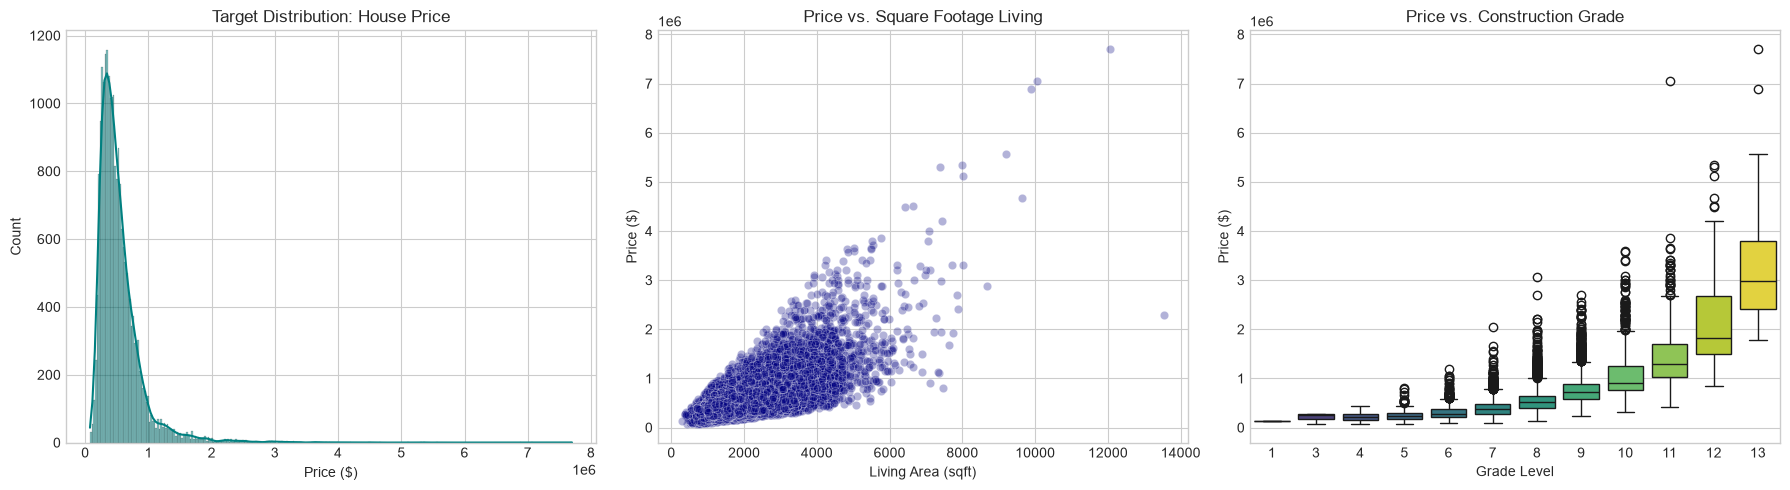

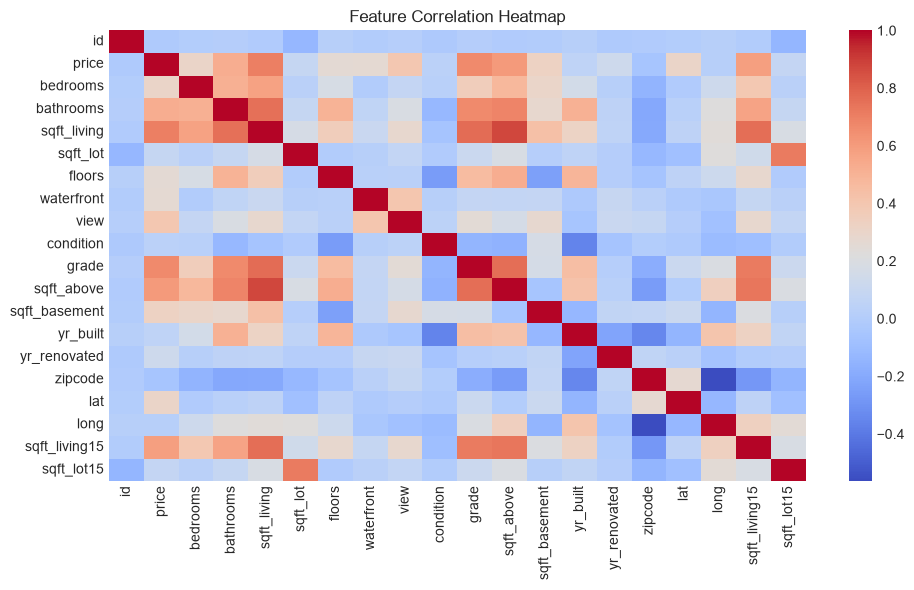

In [7]:
# EDA Visualizations: Target distribution, scatter plot, and grade boxplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Target Distribution
sns.histplot(df_reg['price'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Target Distribution: House Price')
axes[0].set_xlabel('Price ($)')

# 2. Living Area vs Price
sns.scatterplot(data=df_reg, x='sqft_living', y='price', alpha=0.3, ax=axes[1], color='navy')
axes[1].set_title('Price vs. Square Footage Living')
axes[1].set_xlabel('Living Area (sqft)')
axes[1].set_ylabel('Price ($)')

# 3. Grade vs Price
sns.boxplot(data=df_reg, x='grade', y='price', hue='grade', palette='viridis', legend=False, ax=axes[2])
axes[2].set_title('Price vs. Construction Grade')
axes[2].set_xlabel('Grade Level')
axes[2].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 6))
numeric_cols = df_reg.select_dtypes(include=['number'])
sns.heatmap(numeric_cols.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### EDA Observations:
1. **Target Distribution (`price`):** The target distribution exhibits heavy positive (right) skewness; most sales are clustered below $1,000,000, with a long tail of high-value luxury outliers.
2. **Key Predictors:** `sqft_living` shows a strong positive linear relationship with home prices. Construction `grade` displays an exponential tier effect where grades above 9 command substantial premiums.
3. **Multicollinearity:** Features such as `sqft_living`, `sqft_above`, and `sqft_living15` show high mutual correlation, requiring regularization across linear estimators.